# Uncontrolled spring-mass-damper (baseline)

Simulates the free response of the open-loop plant, with no control input and no
noise, using `scipy.integrate.solve_ivp`. Shows the natural damped oscillation
from an initial displacement.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [2]:
# Plant dynamics (no input term): dx/dt = Ax
A = np.array([
    [0.0, 1],               # position rate = 1 * velocity
    [-0.1, -0.1]            # velocity rate = stiffness + damping
])

def smd_dynamics(t, x):
    return A @ x

T = 100        # total simulated time (s)
dt = 0.01      # output sampling step
t_eval = np.arange(0, T, dt)

x0 = [2.0, 0.0]      # initial state: displaced 2 units, at rest

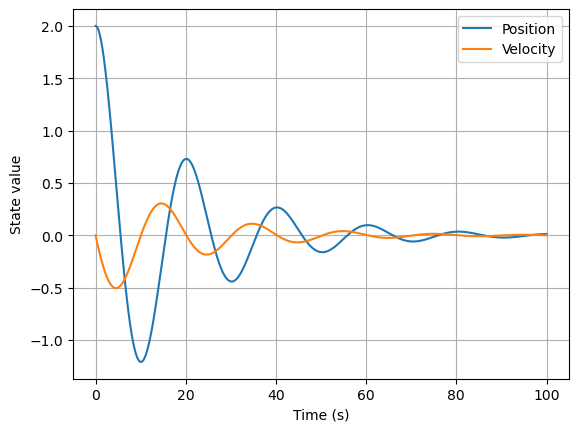

In [3]:
# Integrate the autonomous ODE and plot the free (damped) response
sol = solve_ivp(
    smd_dynamics,
    [0, T],
    x0,
    t_eval=t_eval
)

t = sol.t
position = sol.y[0]
velocity = sol.y[1]

plt.plot(t, position, label="Position")
plt.plot(t, velocity, label="Velocity")

plt.xlabel("Time (s)")
plt.ylabel("State value")
plt.legend()
plt.grid()

plt.show()